# Gurobi Stress Test With Generated Alibaba Instances

This notebook generates feasible-by-construction Alibaba-calibrated instances and solves them with the current MILP formulation. It is intended for early Gurobi scaling tests with the new instance pipeline.

The active compatibility model is resource-based: GPU type, GPU count, CPU, memory, time windows, and power. Job categories are kept only as labels and are not used to decide compatibility.

In [114]:
from __future__ import annotations

from dataclasses import asdict, replace
import json
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.scenarios import DEFAULT_GPU_POWER_KW, build_alibaba_gpu_type_clusters
from src.evaluation.metrics import compute_summary_metrics
from src.evaluation.results import extract_cluster_hourly_results, extract_hourly_results, extract_schedule
from src.instance_generator import SyntheticInstanceConfig, generate_feasible_instance
from src.instance_generator.alibaba_calibration import AlibabaCalibrationConfig, build_alibaba_generator_calibration
from src.milp.gurobi_model import build_milp_model
from src.milp.solve import solve_model

## Experiment Configuration

Start with hourly slots and battery disabled. The goal is to isolate how Gurobi scales with generated jobs before adding 30/15-minute granularity or battery variables.

`GPU_POWER_KW` is still an assumption while final GPU specs are being collected.

In [115]:
OUTPUT_DIR = PROJECT_ROOT / "experiments" / "gurobi_generated_stress"
BASE_CALIBRATION_DIR = PROJECT_ROOT / "experiments" / "outputs" / "alibaba_2023_eda"
RAW_ALIBABA_DIR = PROJECT_ROOT / "data" / "raw" / "alibaba_gpu_v2023"

JOB_COUNTS = [10, 25, 50, 100, 200,500,800,1000,5000,10000,25000, 50000,60000, 100000]
SEEDS = [11]
SLOT_MINUTES = 15
HORIZON_HOURS = 24
MAX_RUNTIME_HOURS_FOR_CALIBRATION = 4.0

CALIBRATION_DIR = BASE_CALIBRATION_DIR if SLOT_MINUTES == 60 else BASE_CALIBRATION_DIR.parent / f"alibaba_2023_eda_{SLOT_MINUTES}min"
CLUSTER_CAPACITY_CSV = CALIBRATION_DIR / "alibaba_cluster_capacity_from_nodes.csv"

TIME_LIMIT_SECONDS = 120
MIP_GAP = 0.01

PUE = 1.2
RENEWABLE_PRICE = 40.0
PEAK_PRICE = 1000.0

# Use a deliberately high value for first scaling smoke tests so peak penalties
# do not dominate while GPU specs and contracted-power scenarios are still open.
CONTRACTED_POWER_MW = 10_000.0

USE_GPU_CONSTRAINTS = True
USE_CPU_CONSTRAINTS = True
USE_MEMORY_CONSTRAINTS = True

# TODO: Replace these defaults once final GPU specs are collected.
GPU_POWER_KW = DEFAULT_GPU_POWER_KW.copy()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

# Durations in Alibaba calibration are stored in slot units. A 60-minute
# calibration cannot be reused for 15-minute or 30-minute generated instances.
build_alibaba_generator_calibration(
    AlibabaCalibrationConfig(
        raw_dir=RAW_ALIBABA_DIR,
        output_dir=CALIBRATION_DIR,
        max_runtime_hours=MAX_RUNTIME_HOURS_FOR_CALIBRATION,
        slot_minutes=SLOT_MINUTES,
    )
)

print(f"Using Alibaba calibration: {CALIBRATION_DIR.relative_to(PROJECT_ROOT)}")
GPU_POWER_KW


Using Alibaba calibration: experiments/outputs/alibaba_2023_eda_15min


{'A10': 0.15,
 'G2': 0.35,
 'G3': 0.35,
 'P100': 0.25,
 'T4': 0.07,
 'V100M16': 0.25,
 'V100M32': 0.25}

## Build Alibaba GPU-Type Clusters

The cluster table uses Alibaba GPU counts plus node-derived aggregate CPU and memory capacity when the calibration CSV is available.

In [116]:
def load_alibaba_node_capacity(path: Path) -> tuple[dict[str, float], dict[str, float]]:
    capacity_df = pd.read_csv(path)
    cpu_capacity = dict(zip(capacity_df["gpu_type"], capacity_df["cpu_capacity"], strict=True))
    memory_capacity = dict(zip(capacity_df["gpu_type"], capacity_df["memory_capacity_gb"], strict=True))
    return cpu_capacity, memory_capacity


if CLUSTER_CAPACITY_CSV.exists():
    cpu_capacity, memory_capacity_gb = load_alibaba_node_capacity(CLUSTER_CAPACITY_CSV)
else:
    cpu_capacity, memory_capacity_gb = None, None

clusters_df = build_alibaba_gpu_type_clusters(
    gpu_power_kw=GPU_POWER_KW,
    cpu_capacity=cpu_capacity,
    memory_capacity_gb=memory_capacity_gb,
)

clusters_df

,cluster_id,cluster_role,capacity_kw,capacity,power_capacity_kw,gpu_type,gpu_count,gpu_capacity,cpu_capacity,memory_capacity_gb
0,cluster_a10,alibaba_gpu_type_pool,0.30,0.00030,0.30,A10,2,2,256.0,2048.0
1,cluster_g2,alibaba_gpu_type_pool,1537.20,1.53720,1537.20,G2,4392,4392,52704.0,210816.0
2,cluster_g3,alibaba_gpu_type_pool,109.20,0.10920,109.20,G3,312,312,4992.0,29952.0
3,cluster_p100,alibaba_gpu_type_pool,66.25,0.06625,66.25,P100,265,265,3160.0,18772.0
4,cluster_t4,alibaba_gpu_type_pool,58.94,0.05894,58.94,T4,842,842,41880.0,204672.0
5,cluster_v100m16,alibaba_gpu_type_pool,48.75,0.04875,48.75,V100M16,195,195,1578.0,6320.0
6,cluster_v100m32,alibaba_gpu_type_pool,51.00,0.05100,51.00,V100M32,204,204,2448.0,19440.0


## Solver Helper

Each run writes the generated instance and, if solved, schedule/hourly/cluster result files. This makes each benchmark row reproducible.

In [117]:
def write_instance(instance_dir: Path, instance) -> None:
    """Persist one generated instance and its solved outputs to disk.

    The notebook uses this helper to keep each benchmark run reproducible by
    writing the generated inputs, hidden schedule, and solver configuration
    alongside any downstream result files.
    """

    instance_dir.mkdir(parents=True, exist_ok=True)
    instance.jobs_df.to_csv(instance_dir / "jobs.csv", index=False)
    instance.hourly_df.to_csv(instance_dir / "hourly_inputs.csv", index=False)
    instance.clusters_df.to_csv(instance_dir / "clusters.csv", index=False)
    instance.hidden_schedule_df.to_csv(instance_dir / "hidden_schedule.csv", index=False)
    (instance_dir / "config.json").write_text(json.dumps(asdict(instance.config), indent=2), encoding="utf-8")


def safe_model_attr(model, attr: str):
    """Return a Gurobi model attribute when available, otherwise `None`.

    Some runs stop early, fail, or do not populate every optional attribute.
    This helper keeps the benchmark loop from crashing when a metric is absent.
    """

    try:
        return getattr(model, attr)
    except Exception:
        return None


def summarize_cluster_utilization(cluster_results: pd.DataFrame) -> dict[str, float]:
    """Return max and mean utilization by resource from solved cluster loads.

    Mean utilization is averaged over cluster-slot rows with positive capacity.
    Max utilization reports the busiest cluster-slot ratio observed for each
    resource.
    """

    resource_pairs = {
        "power": ("cluster_load", "capacity"),
        "gpu": ("cluster_gpu_load", "gpu_capacity"),
        "cpu": ("cluster_cpu_load", "cpu_capacity"),
        "memory": ("cluster_memory_load", "memory_capacity_gb"),
    }
    summary: dict[str, float] = {}
    for resource, (load_column, capacity_column) in resource_pairs.items():
        if load_column not in cluster_results.columns or capacity_column not in cluster_results.columns:
            summary[f"max_{resource}_utilization"] = float("nan")
            summary[f"mean_{resource}_utilization"] = float("nan")
            continue
        frame = cluster_results[[load_column, capacity_column]].copy()
        frame = frame[frame[capacity_column] > 0]
        if frame.empty:
            summary[f"max_{resource}_utilization"] = float("nan")
            summary[f"mean_{resource}_utilization"] = float("nan")
            continue
        utilization = frame[load_column] / frame[capacity_column]
        summary[f"max_{resource}_utilization"] = float(utilization.max())
        summary[f"mean_{resource}_utilization"] = float(utilization.mean())
    return summary


def solve_generated_instance(num_jobs: int, seed: int) -> dict[str, float | int | str | None]:
    """Generate, solve, and summarize one stress-test instance.

    The function builds a feasible-by-construction Alibaba-calibrated instance,
    solves it with the current MILP formulation, exports the instance and
    results, and returns a single row of benchmark metrics.
    """

    run_name = f"jobs_{num_jobs:04d}_seed_{seed}"
    instance_dir = OUTPUT_DIR / run_name

    generator_config = SyntheticInstanceConfig(
        num_jobs=num_jobs,
        horizon_hours=HORIZON_HOURS,
        slot_minutes=SLOT_MINUTES,
        seed=seed,
        sampling_mode="alibaba",
        alibaba_calibration_dir=CALIBRATION_DIR,
        min_window_slack=2,
        max_window_slack=8,
        renewable_price=RENEWABLE_PRICE,
        peak_price=PEAK_PRICE,
        contracted_power=CONTRACTED_POWER_MW,
        pue=PUE,
        power_jitter_fraction=0,
    )
    instance = generate_feasible_instance(generator_config, clusters_df=clusters_df)
    instance = replace(
        instance,
        config=replace(
            instance.config,
            contracted_power=CONTRACTED_POWER_MW,
            renewable_price=RENEWABLE_PRICE,
            peak_price=PEAK_PRICE,
            pue=PUE,
        ),
    )
    write_instance(instance_dir, instance)

    row = {
        "run_name": run_name,
        "num_jobs": num_jobs,
        "seed": seed,
        "slot_minutes": SLOT_MINUTES,
        "horizon_hours": HORIZON_HOURS,
        "instance_dir": str(instance_dir.relative_to(PROJECT_ROOT)),
        "gpu_utilization_ratio": instance.feasibility_report.gpu_utilization_ratio,
        "power_utilization_ratio": instance.feasibility_report.power_utilization_ratio,
        "max_cluster_gpu_utilization": instance.feasibility_report.max_cluster_gpu_utilization,
        "max_cluster_power_utilization": instance.feasibility_report.max_cluster_power_utilization,
    }

    started = time.perf_counter()
    try:
        model, variables = build_milp_model(
            instance.jobs_df,
            instance.hourly_df,
            instance.clusters_df,
            instance.config,
            enforce_gpu_constraints=USE_GPU_CONSTRAINTS,
            enforce_cpu_constraints=USE_CPU_CONSTRAINTS,
            enforce_memory_constraints=USE_MEMORY_CONSTRAINTS,
        )
        model.Params.OutputFlag = 0
        model = solve_model(model, time_limit=TIME_LIMIT_SECONDS, mip_gap=MIP_GAP)
        elapsed = time.perf_counter() - started

        schedule_df = extract_schedule(instance.jobs_df, variables)
        hourly_results = extract_hourly_results(instance.hourly_df, variables)
        cluster_results = extract_cluster_hourly_results(variables)
        metrics = compute_summary_metrics(hourly_results, instance.config)
        utilization_metrics = summarize_cluster_utilization(cluster_results)

        schedule_df.to_csv(instance_dir / "schedule.csv", index=False)
        hourly_results.to_csv(instance_dir / "hourly_results.csv", index=False)
        cluster_results.to_csv(instance_dir / "cluster_hourly_results.csv", index=False)
        pd.DataFrame([metrics]).to_csv(instance_dir / "metrics.csv", index=False)

        row.update(
            {
                "status_code": int(model.Status),
                "status": "solved_or_feasible",
                "sol_count": int(model.SolCount),
                "runtime_s": float(safe_model_attr(model, "Runtime") or elapsed),
                "wall_time_s": float(elapsed),
                "objective": float(model.ObjVal),
                "best_bound": float(safe_model_attr(model, "ObjBound") or model.ObjVal),
                "mip_gap": float(safe_model_attr(model, "MIPGap") or 0.0),
                "num_vars": int(model.NumVars),
                "num_bin_vars": int(model.NumBinVars),
                "num_constraints": int(model.NumConstrs),
                "assignment_vars": len(variables["x"]),
                **metrics,
                **utilization_metrics,
            }
        )
    except Exception as exc:
        elapsed = time.perf_counter() - started
        row.update(
            {
                "status": "failed",
                "error": repr(exc),
                "runtime_s": float(elapsed),
                "wall_time_s": float(elapsed),
            }
        )

    return row

## Run The Stress Ladder

Increase `JOB_COUNTS`, add more `SEEDS`, or lower `TIME_LIMIT_SECONDS` when moving from smoke tests to systematic benchmarks.

In [118]:
rows = []
for num_jobs in JOB_COUNTS:
    for seed in SEEDS:
        print(f"Solving generated instance: jobs={num_jobs}, seed={seed}")
        result = solve_generated_instance(num_jobs, seed)
        rows.append(result)
        print({key: result.get(key) for key in ["status", "runtime_s", "mip_gap", "assignment_vars", "objective", "max_gpu_utilization", "max_cpu_utilization", "max_memory_utilization", "max_power_utilization"]})

results_df = pd.DataFrame(rows)
results_path = OUTPUT_DIR / "gurobi_generated_stress_results.csv"
results_df.to_csv(results_path, index=False)
results_df

Solving generated instance: jobs=10, seed=11
{'status': 'solved_or_feasible', 'runtime_s': 0.008175849914550781, 'mip_gap': 0.0, 'assignment_vars': 751, 'objective': 20.026950000000006, 'max_gpu_utilization': 0.005128205128205128, 'max_cpu_utilization': 0.007642156862745097, 'max_memory_utilization': 0.007278481012658228, 'max_power_utilization': 0.005128205128205128}
Solving generated instance: jobs=25, seed=11
{'status': 'solved_or_feasible', 'runtime_s': 0.0023729801177978516, 'mip_gap': 0.0, 'assignment_vars': 1368, 'objective': 20.11428000000001, 'max_gpu_utilization': 0.005128205128205128, 'max_cpu_utilization': 0.01185551330798479, 'max_memory_utilization': 0.009968354430379746, 'max_power_utilization': 0.0068627450980392165}
Solving generated instance: jobs=50, seed=11
{'status': 'solved_or_feasible', 'runtime_s': 0.00399017333984375, 'mip_gap': 0.0, 'assignment_vars': 2646, 'objective': 20.437589999999993, 'max_gpu_utilization': 0.009615384615384616, 'max_cpu_utilization': 0.0

ValueError: could not place a generated job without violating cluster power/GPU/CPU/memory capacity; reduce num_jobs, duration, GPU demand, or power_per_gpu_kw

## Resource And Energy Bandwidth

Inspect how much of each resource is actually used. Low max utilization means the instance has substantial remaining bandwidth and is unlikely to stress Gurobi through capacity coupling.


In [ ]:
utilization_columns = [
    "num_jobs",
    "assignment_vars",
    "total_energy_mwh",
    "it_energy_mwh",
    "grid_energy_mwh",
    "renewable_energy_mwh",
    "peak_grid_import",
    "max_power_utilization",
    "mean_power_utilization",
    "max_gpu_utilization",
    "mean_gpu_utilization",
    "max_cpu_utilization",
    "mean_cpu_utilization",
    "max_memory_utilization",
    "mean_memory_utilization",
]

existing_columns = [column for column in utilization_columns if column in results_df.columns]
resource_bandwidth_df = results_df[existing_columns].copy()
resource_bandwidth_df


,num_jobs,assignment_vars,total_energy_mwh,it_energy_mwh,grid_energy_mwh,renewable_energy_mwh,peak_grid_import,max_power_utilization,mean_power_utilization,max_gpu_utilization,mean_gpu_utilization,max_cpu_utilization,mean_cpu_utilization,max_memory_utilization,mean_memory_utilization
0,10,751,0.290130,0.241775,0.152466,0.137664,0.012600,0.005128,0.000174,0.005128,0.000198,0.007642,0.000160,0.007278,0.000164
1,25,1368,0.291369,0.242807,0.153312,0.138057,0.012720,0.006863,0.000185,0.005128,0.000178,0.011856,0.000170,0.009968,0.000155
2,50,2646,0.296568,0.247140,0.157098,0.139470,0.013440,0.011028,0.000408,0.009615,0.000464,0.011856,0.000361,0.009968,0.000259
3,100,5218,0.303198,0.252665,0.160374,0.142824,0.014124,0.014930,0.000872,0.010256,0.000742,0.019402,0.000599,0.017247,0.000474
4,200,10308,0.317622,0.264685,0.165624,0.151998,0.015012,0.019897,0.001967,0.025641,0.001961,0.028592,0.001526,0.028210,0.001009
5,50000,2697996,8.596830,7.164025,7.985830,0.611000,1.278032,0.993213,0.217245,1.000000,0.222691,0.989706,0.125847,0.963521,0.089792


## Per-Run Energy And GPU Profiles

Select one solved run and inspect hourly energy sourcing plus GPU load by cluster. By default this uses the largest solved instance in `results_df`.


Selected run: jobs_50000_seed_11 (/Users/juanparrado/Documents/Quantum Master/master_thesis/data_center_scheduling/experiments/gurobi_generated_stress/jobs_50000_seed_11)


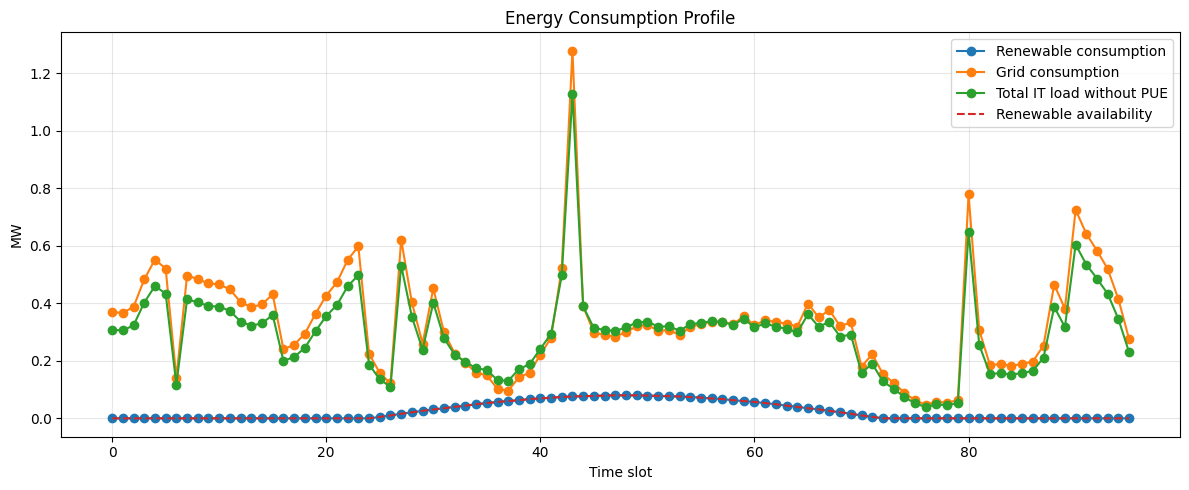

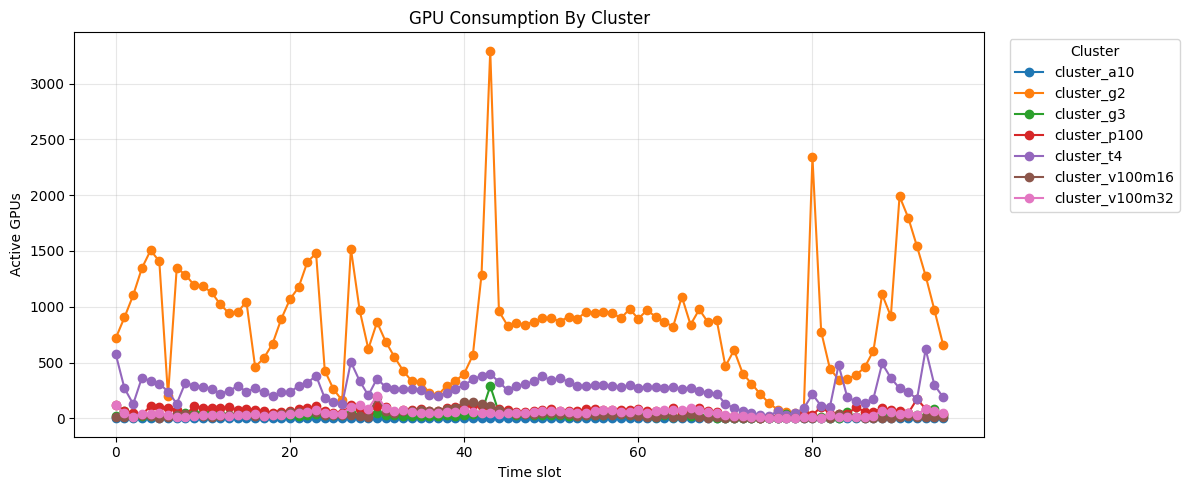

In [ ]:
if results_df.empty or not (results_df["status"] == "solved_or_feasible").any():
    raise ValueError("Run the stress ladder first and make sure at least one case solved.")

# Change this selector if you want to inspect a specific run.
selected_run = (
    results_df[results_df["status"] == "solved_or_feasible"]
    .sort_values(["num_jobs", "seed"], ascending=[False, True])
    .iloc[0]
)
selected_dir = PROJECT_ROOT / selected_run["instance_dir"]
print(f"Selected run: {selected_run['run_name']} ({selected_dir})")

hourly_profile = pd.read_csv(selected_dir / "hourly_results.csv")
cluster_profile = pd.read_csv(selected_dir / "cluster_hourly_results.csv")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_profile["hour"], hourly_profile["renewable_consumption"], marker="o", label="Renewable consumption")
ax.plot(hourly_profile["hour"], hourly_profile["grid_consumption"], marker="o", label="Grid consumption")
ax.plot(hourly_profile["hour"], hourly_profile["it_load"], marker="o", label="Total IT load without PUE")
ax.plot(hourly_profile["hour"], hourly_profile["renewable_available"], linestyle="--", label="Renewable availability")
ax.set_title("Energy Consumption Profile")
ax.set_xlabel("Time slot")
ax.set_ylabel("MW")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gpu_pivot = cluster_profile.pivot_table(
    index="hour",
    columns="cluster_id",
    values="cluster_gpu_load",
    aggfunc="sum",
    fill_value=0.0,
)

fig, ax = plt.subplots(figsize=(12, 5))
gpu_pivot.plot(ax=ax, marker="o")
ax.set_title("GPU Consumption By Cluster")
ax.set_xlabel("Time slot")
ax.set_ylabel("Active GPUs")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Scaling Plots

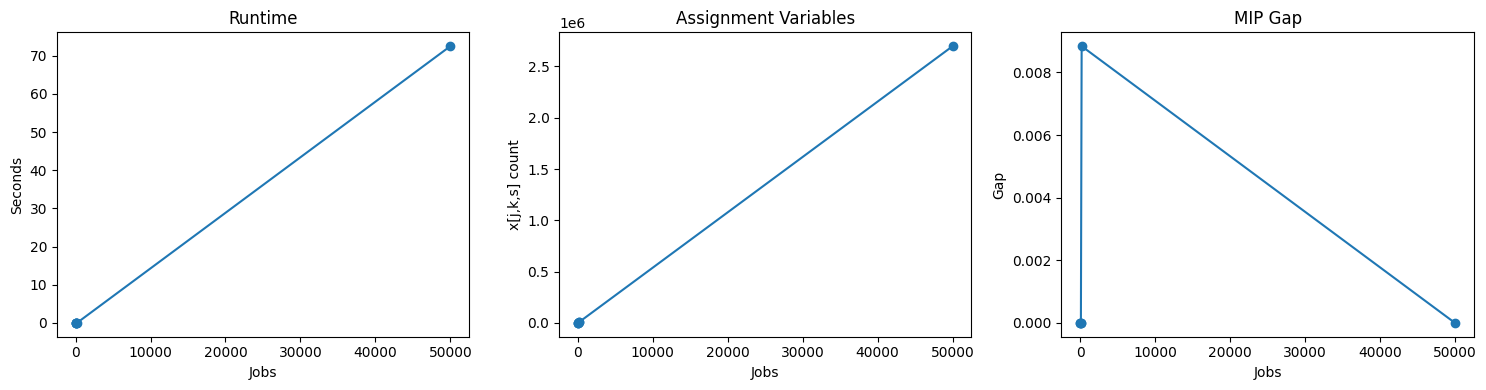

In [ ]:
if not results_df.empty:
    solved_df = results_df[results_df["status"] == "solved_or_feasible"].copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(results_df["num_jobs"], results_df["runtime_s"], marker="o")
    axes[0].set_title("Runtime")
    axes[0].set_xlabel("Jobs")
    axes[0].set_ylabel("Seconds")

    if "assignment_vars" in results_df:
        axes[1].plot(results_df["num_jobs"], results_df["assignment_vars"], marker="o")
    axes[1].set_title("Assignment Variables")
    axes[1].set_xlabel("Jobs")
    axes[1].set_ylabel("x[j,k,s] count")

    if not solved_df.empty and "mip_gap" in solved_df:
        axes[2].plot(solved_df["num_jobs"], solved_df["mip_gap"], marker="o")
    axes[2].set_title("MIP Gap")
    axes[2].set_xlabel("Jobs")
    axes[2].set_ylabel("Gap")

    plt.tight_layout()
    plt.show()

## Interpreting Results

- If runtime is very low for all job counts, increase jobs, widen windows, add seeds, or move to 30-minute slots.
- If generation fails, the requested workload is too dense for the current cluster capacities and time horizon.
- If Gurobi finds feasible solutions but not optimality, inspect `mip_gap`, `best_bound`, and `assignment_vars`.
- If power utilization is always tiny, final GPU power specs or contracted-power scenarios may be too loose for energy stress testing.
- Keep battery disabled until the base generated-instance scaling behavior is understood.